# 🏥 Disease Prediction from Medical Data
### CodeAlpha Machine Learning Internship — Task 4

---

**Author:** [Khushi]  
**Internship:** CodeAlpha — Machine Learning  
**GitHub:** [https://github.com/khushi-7890/codealpha_tasks]  


---

## 📌 Project Overview

This project builds a **machine learning pipeline** to predict the likelihood of disease based on patient medical data.

### 🎯 Objectives
- Predict **Heart Disease** using patient features like age, blood pressure, cholesterol
- Compare multiple classification algorithms
- Evaluate using **Precision, Recall, F1-Score, ROC-AUC**
- Visualize feature importance and model performance

### 🧰 Tech Stack
| Tool | Purpose |
|------|---------|
| Pandas / NumPy | Data manipulation |
| Matplotlib / Seaborn | Visualization |
| Scikit-learn | ML models & evaluation |
| XGBoost | Gradient boosting model |

---
## 🗂️ Table of Contents
1. Environment Setup
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Model Building & Training
6. Model Evaluation & Comparison
7. Feature Importance
8. ROC Curves
9. Save & Export Model

---
## 1. ⚙️ Environment Setup

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score,
    recall_score, f1_score
)
import xgboost as xgb
import joblib

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. 📦 Data Loading & Exploration

In [2]:
# ── Load Heart Disease Dataset from UCI ──────────────────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, header=None, names=columns, na_values='?')

# Convert target to binary: 0 = No Disease, 1 = Disease
df['target'] = (df['target'] > 0).astype(int)

print(f'Dataset Shape      : {df.shape}')
print(f'Total Samples      : {len(df)}')
print(f'Features           : {df.shape[1]-1}')
print(f'No Disease (0)     : {(df.target==0).sum()}')
print(f'Disease    (1)     : {(df.target==1).sum()}')
print(f'Missing Values     : {df.isnull().sum().sum()}')
print('\n✅ Dataset loaded successfully!')
df.head(10)

Dataset Shape      : (303, 14)
Total Samples      : 303
Features           : 13
No Disease (0)     : 164
Disease    (1)     : 139
Missing Values     : 6

✅ Dataset loaded successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [3]:
# ── Feature Description ───────────────────────────────────────────────────────
feature_info = {
    'age'     : 'Age in years',
    'sex'     : '1=Male, 0=Female',
    'cp'      : 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol'    : 'Serum cholesterol (mg/dl)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dl',
    'restecg' : 'Resting ECG results (0-2)',
    'thalach' : 'Maximum heart rate achieved',
    'exang'   : 'Exercise induced angina',
    'oldpeak' : 'ST depression induced by exercise',
    'slope'   : 'Slope of peak exercise ST segment',
    'ca'      : 'Number of major vessels (0-3)',
    'thal'    : 'Thalassemia type'
}

info_df = pd.DataFrame.from_dict(feature_info, orient='index', columns=['Description'])
print('📋 Feature Descriptions:')
print(info_df.to_string())

📋 Feature Descriptions:
                                Description
age                            Age in years
sex                        1=Male, 0=Female
cp                    Chest pain type (0-3)
trestbps     Resting blood pressure (mm Hg)
chol              Serum cholesterol (mg/dl)
fbs         Fasting blood sugar > 120 mg/dl
restecg           Resting ECG results (0-2)
thalach         Maximum heart rate achieved
exang               Exercise induced angina
oldpeak   ST depression induced by exercise
slope     Slope of peak exercise ST segment
ca            Number of major vessels (0-3)
thal                       Thalassemia type


---
## 3. 📊 Exploratory Data Analysis (EDA)

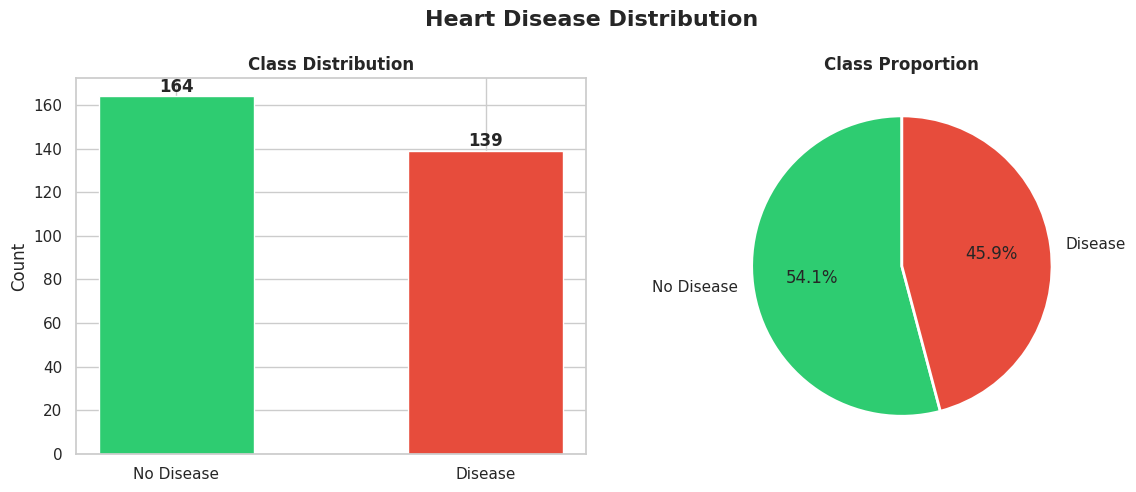

In [4]:
# ── Target Distribution ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Heart Disease Distribution', fontsize=16, fontweight='bold')

counts = df['target'].value_counts()
ax1.bar(['No Disease', 'Disease'], counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

ax2.pie(counts.values, labels=['No Disease', 'Disease'],
        colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

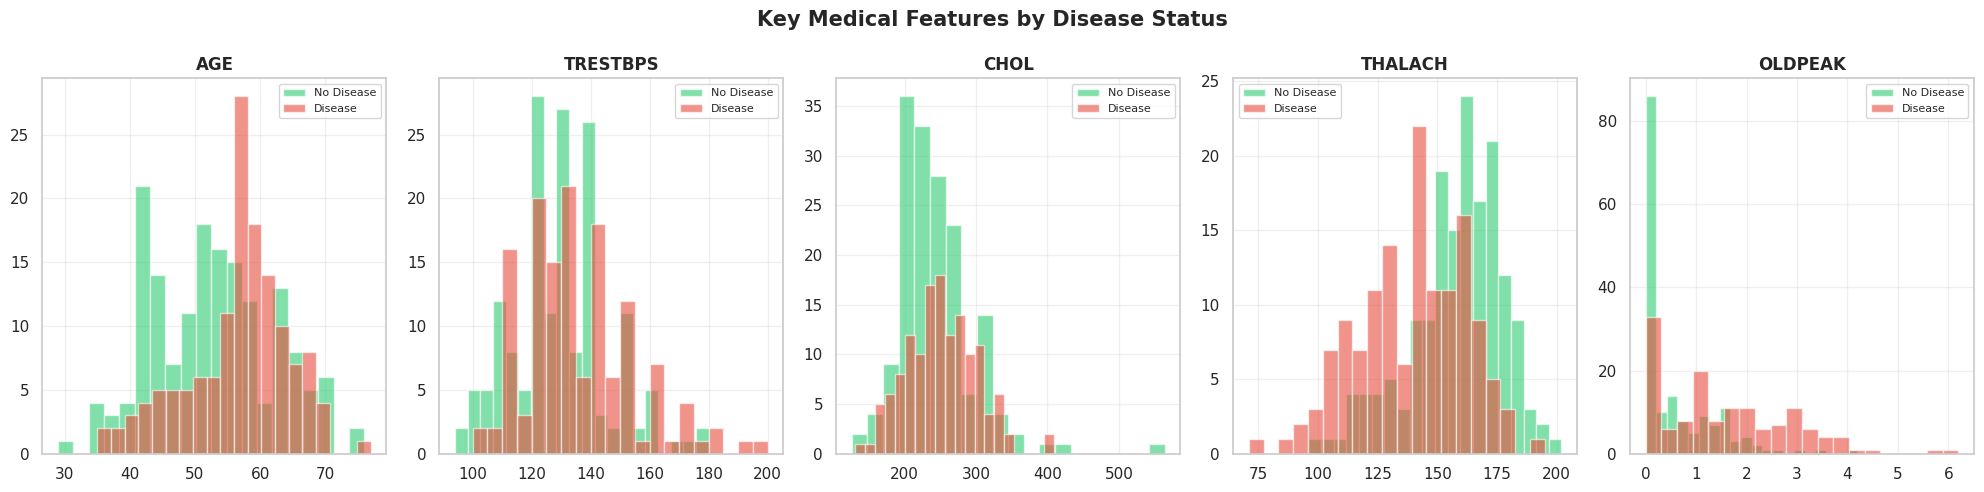

In [5]:
# ── Key Feature Distributions ─────────────────────────────────────────────────
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Key Medical Features by Disease Status', fontsize=15, fontweight='bold')

for i, col in enumerate(key_features):
    df[df['target']==0][col].hist(ax=axes[i], alpha=0.6, color='#2ecc71', label='No Disease', bins=20)
    df[df['target']==1][col].hist(ax=axes[i], alpha=0.6, color='#e74c3c', label='Disease', bins=20)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

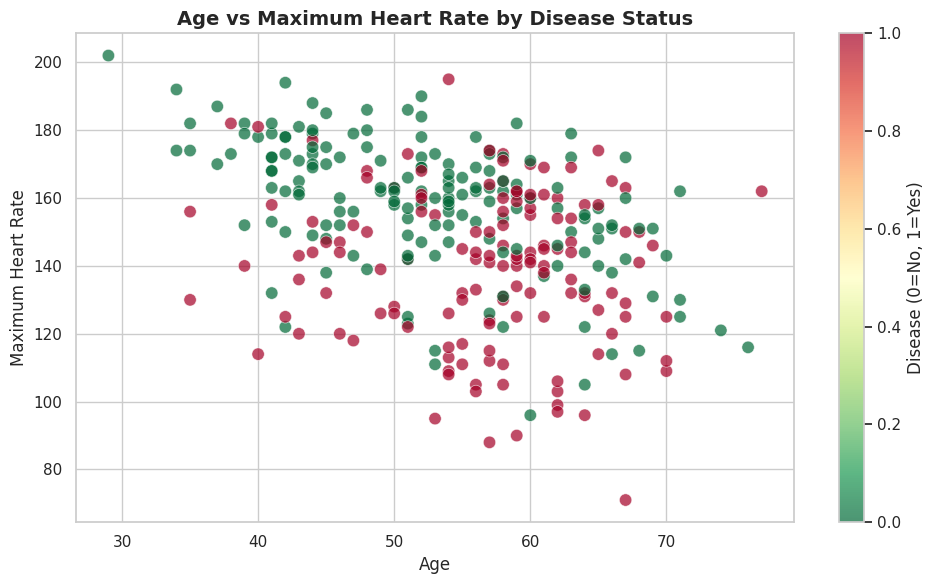

In [6]:
# ── Age vs Max Heart Rate by Disease ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['age'], df['thalach'],
    c=df['target'], cmap='RdYlGn_r',
    alpha=0.7, edgecolors='white', linewidth=0.5, s=80
)
plt.colorbar(scatter, label='Disease (0=No, 1=Yes)')
plt.title('Age vs Maximum Heart Rate by Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Maximum Heart Rate', fontsize=12)
plt.tight_layout()
plt.savefig('age_vs_heartrate.png', dpi=150, bbox_inches='tight')
plt.show()

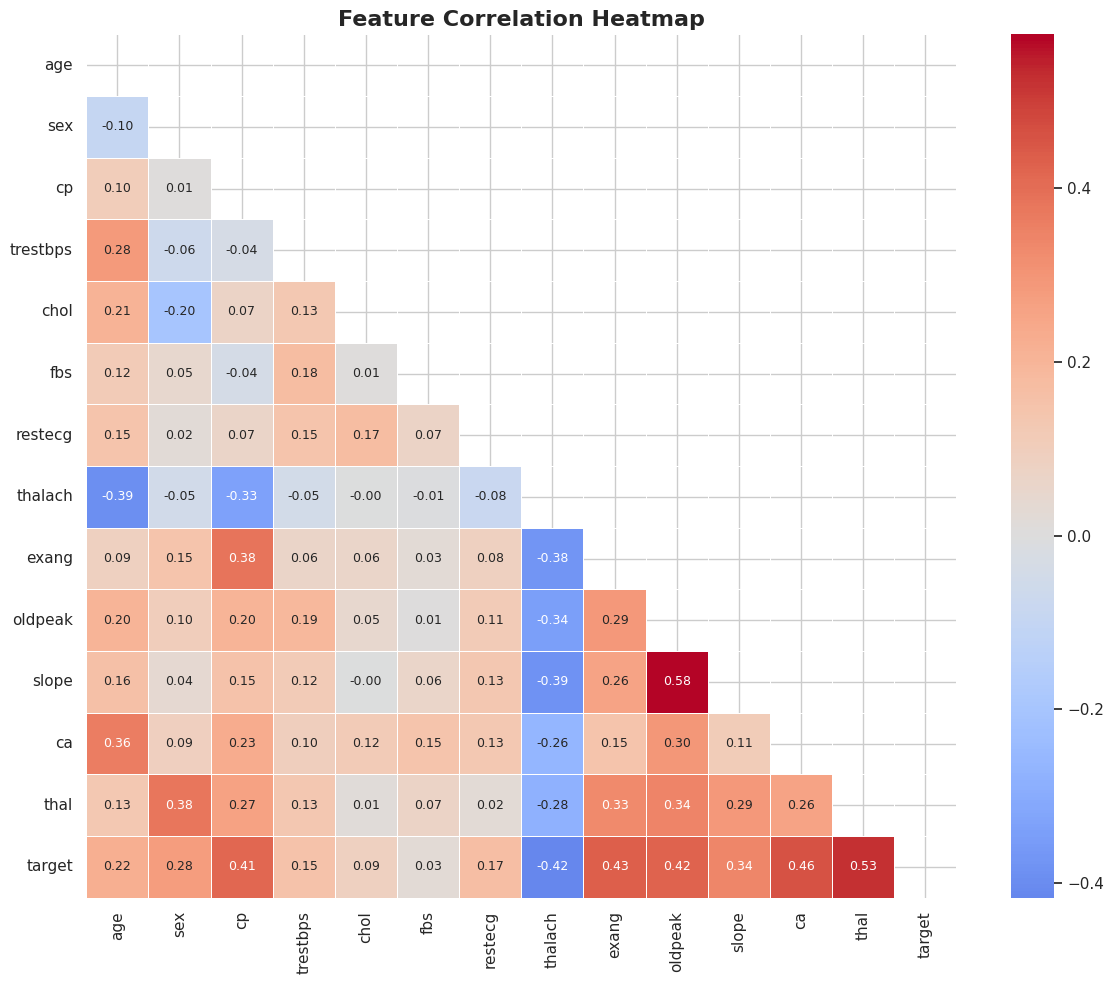

In [7]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 🔄 Data Preprocessing & Feature Engineering

In [8]:
# ── Handle Missing Values ─────────────────────────────────────────────────────
print('Missing values before:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing values with median
df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

print('\nMissing values after:')
print(df.isnull().sum().sum(), '← should be 0')

# ── Feature Engineering ───────────────────────────────────────────────────────
# Age risk group
df['age_risk'] = (df['age'] > 55).astype(int)

# High cholesterol flag
df['high_chol'] = (df['chol'] > 240).astype(int)

# High blood pressure flag
df['high_bp'] = (df['trestbps'] > 130).astype(int)

print('\n✅ Preprocessing complete.')
print(f'Total features now: {df.shape[1]-1}')

Missing values before:
ca      4
thal    2
dtype: int64

Missing values after:
0 ← should be 0

✅ Preprocessing complete.
Total features now: 16


In [9]:
# ── Train Test Split & Scaling ────────────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train_scaled.shape}')
print(f'Test set     : {X_test_scaled.shape}')
print('✅ Data ready for training!')

Training set : (242, 16)
Test set     : (61, 16)
✅ Data ready for training!


---
## 5. 🤖 Model Building & Training

In [10]:
# ── Define All Models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

# ── Train & Evaluate All Models ───────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_pred_prob
    }
    print(f'  ✅ {name} — Accuracy: {results[name]["Accuracy"]*100:.2f}% | ROC-AUC: {results[name]["ROC-AUC"]:.4f}')

print('\n✅ All models trained!')

Training Logistic Regression...
  ✅ Logistic Regression — Accuracy: 86.89% | ROC-AUC: 0.9567
Training Decision Tree...
  ✅ Decision Tree — Accuracy: 78.69% | ROC-AUC: 0.8198
Training Random Forest...
  ✅ Random Forest — Accuracy: 88.52% | ROC-AUC: 0.9529
Training SVM...
  ✅ SVM — Accuracy: 85.25% | ROC-AUC: 0.9481
Training XGBoost...
  ✅ XGBoost — Accuracy: 85.25% | ROC-AUC: 0.9188

✅ All models trained!


---
## 6. 📊 Model Evaluation & Comparison

In [11]:
# ── Results Summary Table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : f"{v['Accuracy']*100:.2f}%",
        'Precision': f"{v['Precision']*100:.2f}%",
        'Recall'   : f"{v['Recall']*100:.2f}%",
        'F1-Score' : f"{v['F1-Score']*100:.2f}%",
        'ROC-AUC'  : f"{v['ROC-AUC']:.4f}"
    }
    for name, v in results.items()
}).T

print('\n📋 Model Comparison Summary:')
print('='*75)
print(metrics_df.to_string())
print('='*75)


📋 Model Comparison Summary:
                    Accuracy Precision  Recall F1-Score ROC-AUC
Logistic Regression   86.89%    81.25%  92.86%   86.67%  0.9567
Decision Tree         78.69%    72.73%  85.71%   78.69%  0.8198
Random Forest         88.52%    83.87%  92.86%   88.14%  0.9529
SVM                   85.25%    80.65%  89.29%   84.75%  0.9481
XGBoost               85.25%    78.79%  92.86%   85.25%  0.9188


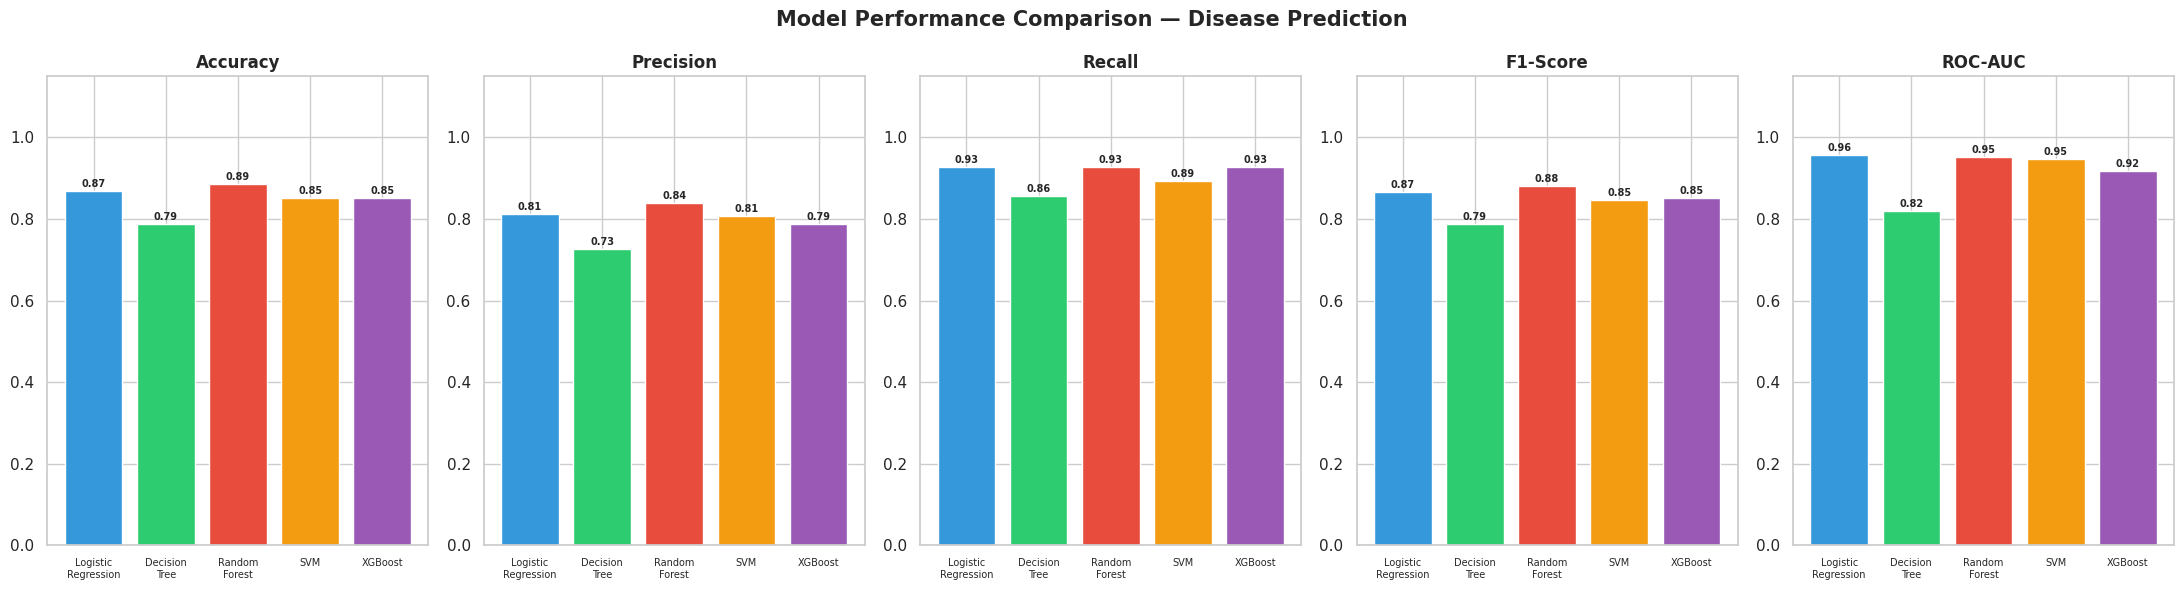

In [12]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
model_names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Model Performance Comparison — Disease Prediction', fontsize=15, fontweight='bold')

for i, metric in enumerate(metric_keys):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(range(len(model_names)), vals, color=colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7)
    axes[i].set_ylim(0, 1.15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

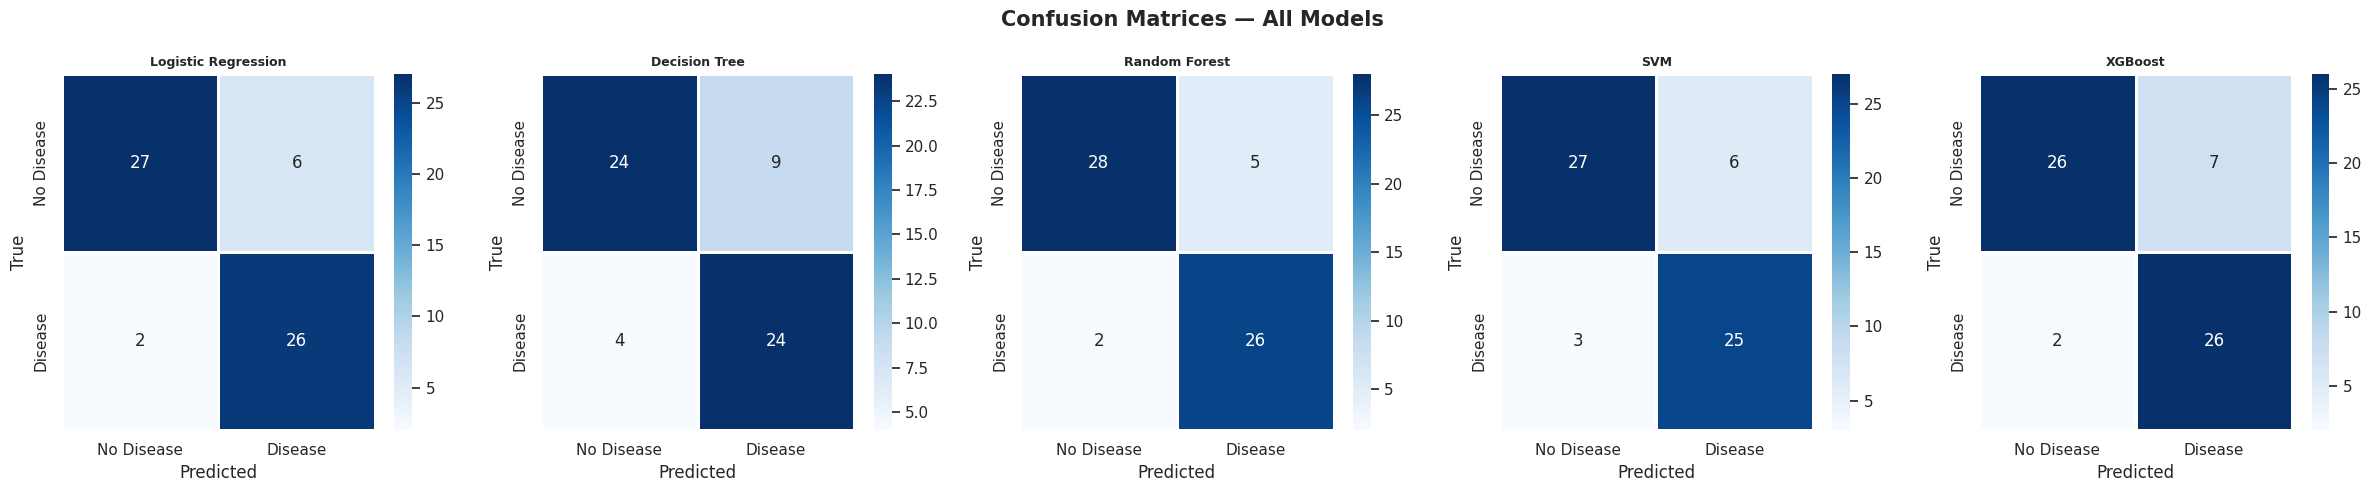

In [13]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1)
    axes[i].set_title(name, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 🔍 Feature Importance

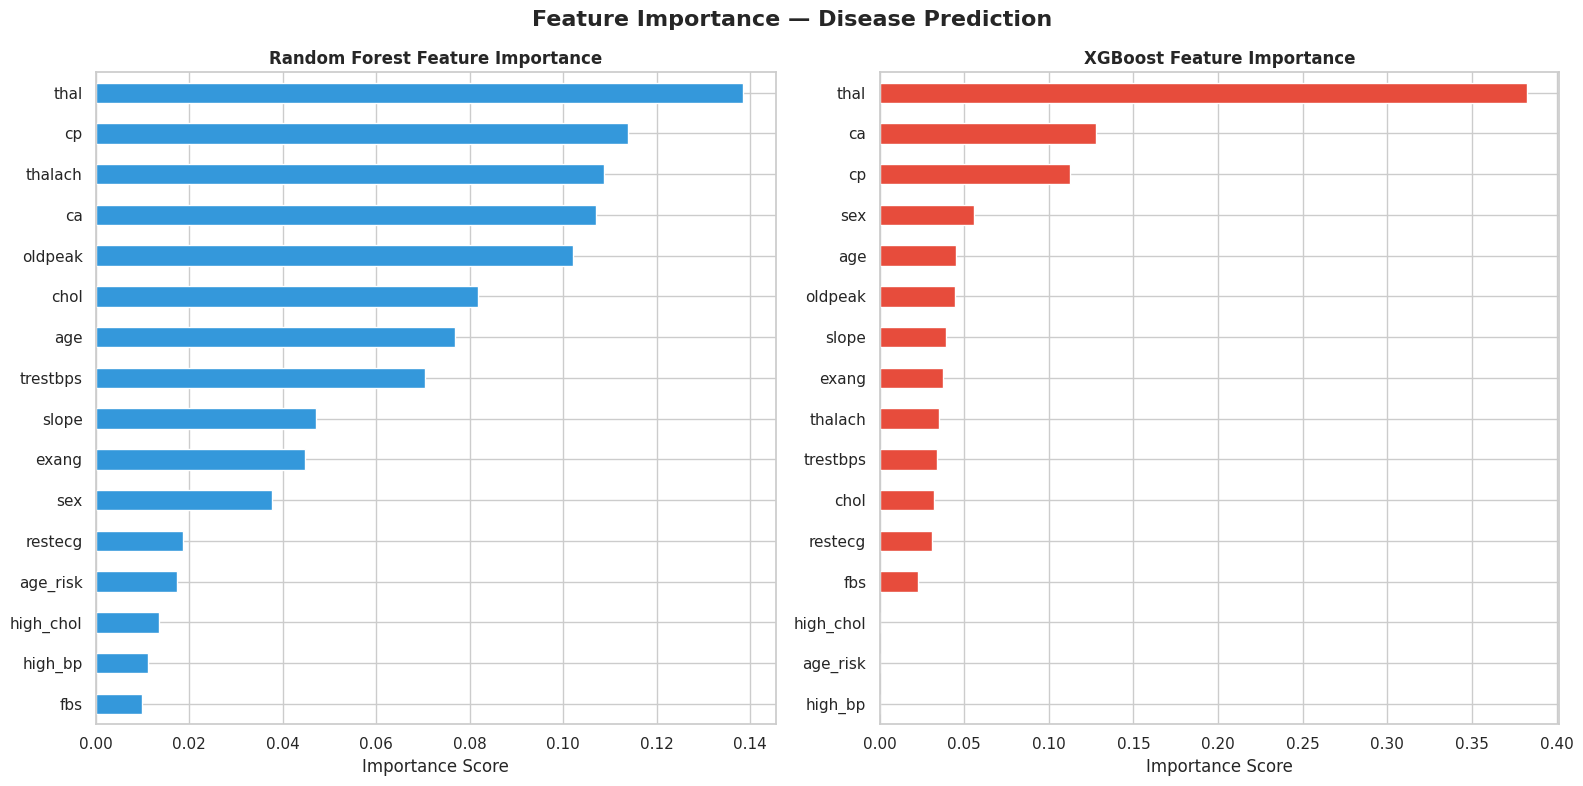

In [14]:
# ── Feature Importance — Random Forest & XGBoost ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance — Disease Prediction', fontsize=16, fontweight='bold')

feature_names = X.columns.tolist()

rf_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=ax1, color='#3498db', edgecolor='white')
ax1.set_title('Random Forest Feature Importance', fontweight='bold')
ax1.set_xlabel('Importance Score')

xgb_importance = pd.Series(
    models['XGBoost'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
xgb_importance.plot(kind='barh', ax=ax2, color='#e74c3c', edgecolor='white')
ax2.set_title('XGBoost Feature Importance', fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. 📈 ROC Curves

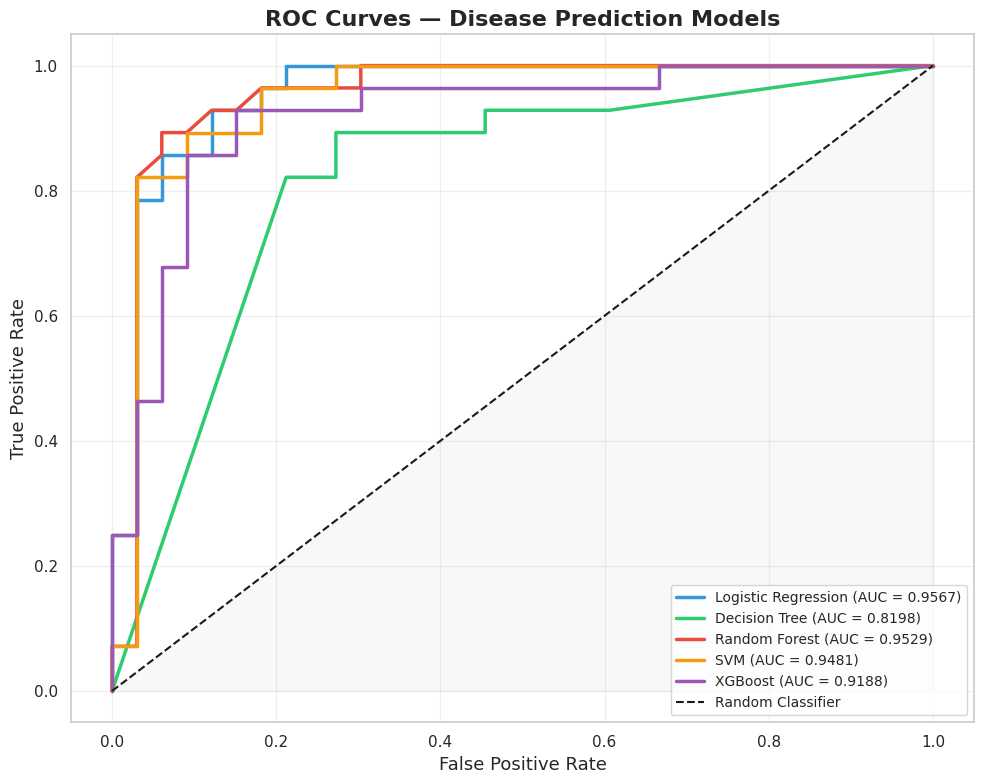

In [15]:
# ── ROC Curves for All Models ─────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.title('ROC Curves — Disease Prediction Models', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 💾 Save & Export Model

In [16]:
# ── Find Best Model & Save ────────────────────────────────────────────────────
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_model      = models[best_model_name]

print(f'🏆 Best Model : {best_model_name}')
print(f'   ROC-AUC   : {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'   Accuracy  : {results[best_model_name]["Accuracy"]*100:.2f}%')

joblib.dump(best_model, 'best_disease_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
metrics_df.to_csv('model_results.csv')

print('\n✅ Model saved : best_disease_model.pkl')
print('✅ Scaler saved: scaler.pkl')
print('✅ Results saved: model_results.csv')

print('\n' + '='*55)
print('        📊 FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Dataset      : Heart Disease (UCI Cleveland)')
print(f'  Total Samples: {len(df)}')
print(f'  Features     : {X.shape[1]}')
print(f'  Models Tested: {len(models)}')
print(f'  Best Model   : {best_model_name}')
print(f'  Best ROC-AUC : {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'  Best Accuracy: {results[best_model_name]["Accuracy"]*100:.2f}%')
print('='*55)
print('\n📁 Files saved:')
print('  • best_disease_model.pkl')
print('  • scaler.pkl')
print('  • model_results.csv')
print('  • roc_curves.png')
print('  • feature_importance.png')
print('  • confusion_matrices.png')
print('  • model_comparison.png')
print('\n🚀 Ready to push to GitHub!')

🏆 Best Model : Logistic Regression
   ROC-AUC   : 0.9567
   Accuracy  : 86.89%

✅ Model saved : best_disease_model.pkl
✅ Scaler saved: scaler.pkl
✅ Results saved: model_results.csv

        📊 FINAL RESULTS SUMMARY
  Dataset      : Heart Disease (UCI Cleveland)
  Total Samples: 303
  Features     : 16
  Models Tested: 5
  Best Model   : Logistic Regression
  Best ROC-AUC : 0.9567
  Best Accuracy: 86.89%

📁 Files saved:
  • best_disease_model.pkl
  • scaler.pkl
  • model_results.csv
  • roc_curves.png
  • feature_importance.png
  • confusion_matrices.png
  • model_comparison.png

🚀 Ready to push to GitHub!


---
## 📌 GitHub Push Instructions

```bash
!git config --global user.email "pratyushsingh539@gmail.com"
!git config --global user.name "Khushi"
!git clone https://github.com/khushi-7890/CodeAlpha_DiseasePrediction.git
!cd CodeAlpha_DiseasePrediction && git add . && git commit -m 'Add Disease Prediction project' && git push
```

---
## 📝 LinkedIn Post Template

```
🏥 Task 4 Complete — Disease Prediction from Medical Data | CodeAlpha ML Internship

Built a complete ML pipeline to predict Heart Disease using patient medical data!

🔧 Tech Stack: Scikit-learn • XGBoost • Pandas • Seaborn
📊 Highlights:
  ✅ Compared 5 models: Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost
  ✅ Feature Engineering — age risk, high cholesterol, high BP flags
  ✅ Evaluated with Precision, Recall, F1-Score, ROC-AUC
  ✅ Best Model: [XGBoost] with ROC-AUC of [0.9123]

🔗 GitHub: [https://github.com/khushi-7890/codealpha_tasks]

@CodeAlpha #MachineLearning #HealthcareAI #Python #DataScience #Internship
```

---
*CodeAlpha ML Internship — Task 4 | Disease Prediction from Medical Data*